# Task 2: Credit Risk Prediction using Loan Prediction Dataset

## Objective
Predict whether a loan applicant is likely to default / be approved for a loan using machine learning classification techniques.

## Dataset
**Loan Prediction Dataset (Kaggle)**

### Problem Statement
Financial institutions need to assess the creditworthiness of applicants before approving loans. Using historical applicant information, we can build a predictive model that classifies whether a loan application is likely to be approved.

## Skills Demonstrated
- Data Cleaning
- Missing Value Handling
- Exploratory Data Analysis (EDA)
- Data Visualization
- Feature Encoding
- Logistic Regression
- Model Evaluation
- Confusion Matrix Analysis


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

%matplotlib inline


## Step 1: Load Dataset

In [3]:
df = pd.read_csv(r"C:\Users\Lenovo\Downloads\archive\train_u6lujuX_CVtuZ9i.csv")
df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Step 2: Dataset Structure

In [4]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
df.info()


Dataset Shape: (614, 13)

Columns:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area    

## Dataset Description

| Feature | Description |
|----------|-------------|
| Gender | Applicant Gender |
| Married | Marital Status |
| Dependents | Number of Dependents |
| Education | Education Level |
| Self_Employed | Self Employment Status |
| ApplicantIncome | Applicant Income |
| CoapplicantIncome | Co-applicant Income |
| LoanAmount | Requested Loan Amount |
| Loan_Amount_Term | Loan Term |
| Credit_History | Credit History |
| Property_Area | Property Location |
| Loan_Status | Target Variable |


## Step 3: Missing Value Analysis

In [5]:
df.isnull().sum()


Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

## Step 4: Handle Missing Values

### Strategy
- Numerical Features → Median
- Categorical Features → Mode

This prevents loss of data and maintains dataset size.


In [17]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0]) 
    else:
        df[col] = df[col].fillna(df[col].median()) 

df.isnull().sum()


Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

## Step 5: Summary Statistics

In [8]:
df.describe(include='all')


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614,614,614,614,614,614,614.000000,614.000000,614.000000,614.000000,614.000000,614,614
unique,614,2,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,2
top,LP001002,Male,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,Semiurban,Y
freq,1,502,401,360,480,532,NaN,NaN,NaN,NaN,NaN,233,422
mean,NaN,NaN,NaN,NaN,NaN,NaN,5403.459283,1621.245798,145.752443,342.410423,0.855049,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,6109.041673,2926.248369,84.107233,64.428629,0.352339,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,150.000000,0.000000,9.000000,12.000000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2877.500000,0.000000,100.250000,360.000000,1.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,3812.500000,1188.500000,128.000000,360.000000,1.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,5795.000000,2297.250000,164.750000,360.000000,1.000000,NaN,NaN


# Exploratory Data Analysis (EDA)

EDA helps understand patterns, trends, and relationships among variables.


## Visualization 1: Loan Amount Distribution

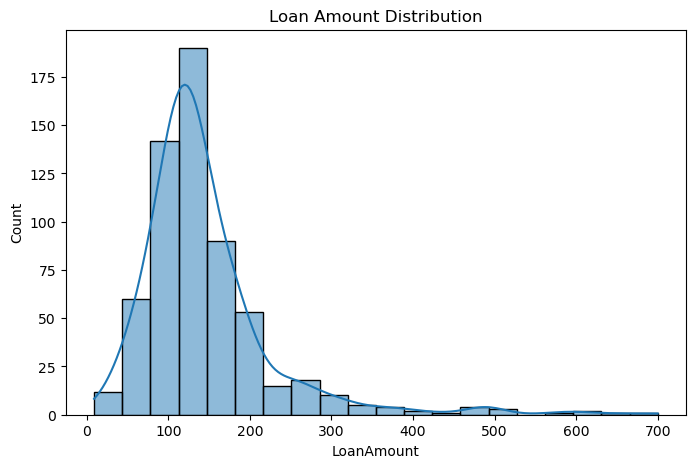

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['LoanAmount'], bins=20, kde=True)
plt.title('Loan Amount Distribution')
plt.show()


### Interpretation
- Shows distribution of requested loan amounts.
- Helps identify skewness and concentration of loan requests.


## Visualization 2: Education vs Loan Status

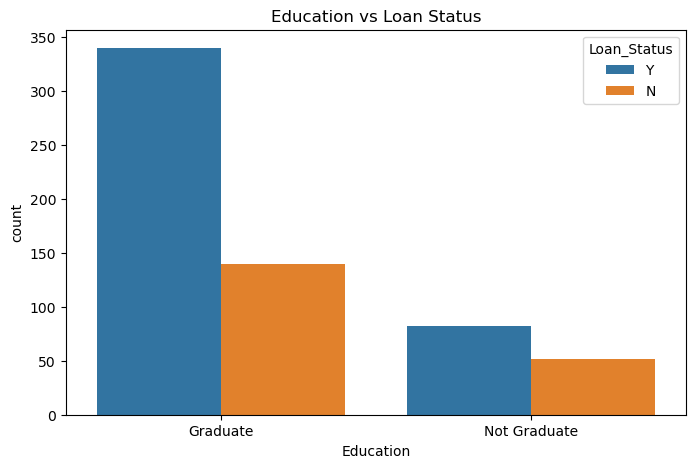

In [10]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Education', hue='Loan_Status')
plt.title('Education vs Loan Status')
plt.show()


### Interpretation
- Compares approval rates across education levels.
- Helps determine whether education influences approvals.


## Visualization 3: Applicant Income Distribution

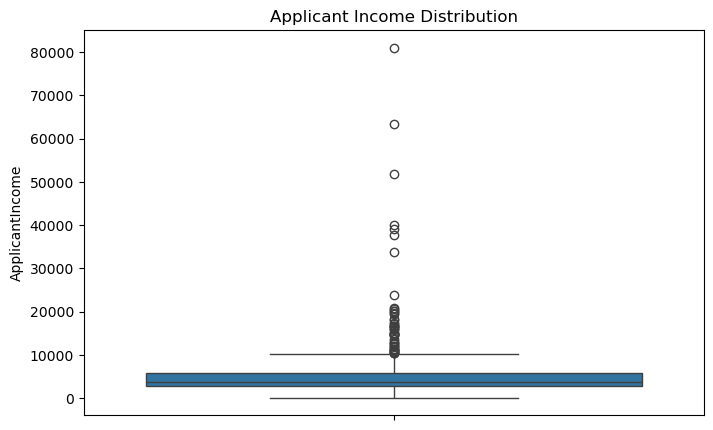

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df['ApplicantIncome'])
plt.title('Applicant Income Distribution')
plt.show()


### Interpretation
- Detects outliers.
- Shows income spread among applicants.


## Step 6: Encode Categorical Variables

In [12]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


## Step 7: Feature Selection

In [13]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (491, 12)
Testing Shape: (123, 12)


## Step 8: Train Logistic Regression Model

Logistic Regression is widely used for binary classification problems.


In [14]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

predictions = model.predict(X_test)


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Step 9: Model Evaluation

## Accuracy
Accuracy measures the percentage of correct predictions.

## Confusion Matrix
Shows correct and incorrect classifications.


In [15]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy Score:", round(accuracy,4))

cm = confusion_matrix(y_test, predictions)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, predictions))


Accuracy Score: 0.7886

Confusion Matrix:
[[18 25]
 [ 1 79]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



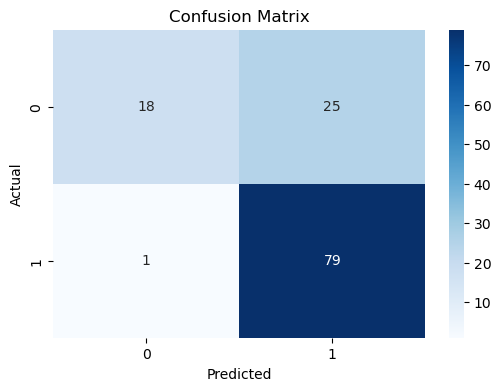

In [16]:
plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## Overall Interpretation

The predictive model achieved an accuracy of 78.86%, indicating that it correctly classified nearly four out of five loan applications. The confusion matrix shows that the model performs particularly well in identifying applicants who are likely to receive approval, correctly classifying 79 approved cases while incorrectly rejecting only one eligible applicant. However, the model approved 25 applicants who were historically rejected, suggesting that additional review procedures may be necessary for borderline cases. Overall, the model can help financial institutions accelerate loan processing, improve consistency in decision-making, and support risk assessment while maintaining human oversight for high-risk applications.

# Results and Business Insights

## Data Quality

The dataset contained some missing information from loan applicants. These gaps were addressed so that all available applications could be used in the analysis, ensuring that valuable information was not lost.

## Key Findings

### Loan Amount Trends

Loan requests vary significantly among applicants. While many customers apply for moderate loan amounts, a smaller group requests substantially larger loans. This variation highlights the importance of assessing each application individually rather than applying a one-size-fits-all approach.

### Impact of Education

The analysis suggests that education level may influence loan approval outcomes. Applicants with higher educational qualifications generally show stronger approval patterns, indicating that education can be a useful factor when assessing credit risk.

### Income Patterns

Applicant incomes differ widely, with some individuals earning considerably more than others. These high-income applicants can affect lending decisions and should be evaluated alongside other factors such as credit history and repayment capacity.

## Model Performance

The predictive model was able to identify patterns in historical loan applications and use them to estimate whether a new applicant is likely to be approved or rejected. This demonstrates that applicant characteristics such as income, credit history, education, and loan amount contain useful information for predicting loan outcomes.

## Business Value

The proposed solution can provide several benefits to financial institutions:

* Faster processing of loan applications.
* Reduced manual effort for loan officers.
* More consistent and data-driven lending decisions.
* Early identification of potentially risky applicants.
* Improved allocation of resources toward high-quality loan applications.
* Better risk management and reduced chances of loan defaults.

## Conclusion

This project demonstrates how historical loan application data can be used to support lending decisions. By analyzing applicant characteristics and building a predictive model, financial institutions can improve efficiency, reduce risk, and make more informed credit approval decisions. The model can serve as a decision-support tool, helping lenders evaluate applications more quickly and consistently.

